## Import necessary packages

In [1]:
import numpy as np

from sequentialized_barnard_tests.tools.plotting import (
    compare_success_and_get_cld,
    plot_model_comparison,
)

## Specify your statistical analysis plan before collecting policy rollouts:

In [2]:
global_confidence_level = 0.95  # Global confidence level across 6 pairwise comparisons.
max_sample_size_per_model = 15  # Maximum possible number of rollouts (per method), according to your evaluation budget.
shuffle = False  # Whether to shuffle the True/False ordering in each success array. Set to False here, assuming each True/False outcome is independent within each success_array.

## Suppose you performed some rollouts and got the following intermediate results:

In [3]:
model_name_list = [
    "Policy A",
    "Policy B",
    "Policy C",
]

success_array_list = [
    np.array([True, False, False, False, False, False, True, False, False, False]),  # For Method A. False indicates failure.
    np.array([True, True, True, False, True, True, True, True, True, True]),  # For Method B. False indicates failure.
    np.array([False, False, True, True, False, False, False, True, True, False]),  # For Method C. False indicates failure.
]

## Run the statistical test at any time during your experiment:

In [4]:
cld_dict = compare_success_and_get_cld(
    model_name_list,
    success_array_list,
    global_confidence_level,
    max_sample_size_per_model,
    shuffle,
    verbose=True,
)
cld_list = [cld_dict[key] for key in model_name_list]

Statistical Test Specs:
  Method: STEP
  Global Confidence: 0.95
    (0.98333 per comparison)
  Maximum Sample Size per Model: 15

Statistical Test Results (Compact Letter Display):
  CLD for Policy B: a
    Success Rate 9 / 10 = 0.9
  CLD for Policy C: ab
    Success Rate 4 / 10 = 0.4
  CLD for Policy A: b
    Success Rate 2 / 10 = 0.2
Not all models were separated with global confidence of 0.95. Models that share a same letter are not separated from each other with statistical significance. For more information on how to interpret the letters, see: https://en.wikipedia.org/wiki/Compact_letter_display.



## Let's visualize this comparison:

Plot generated. Two models that do not share any CLD letters are significantly different.


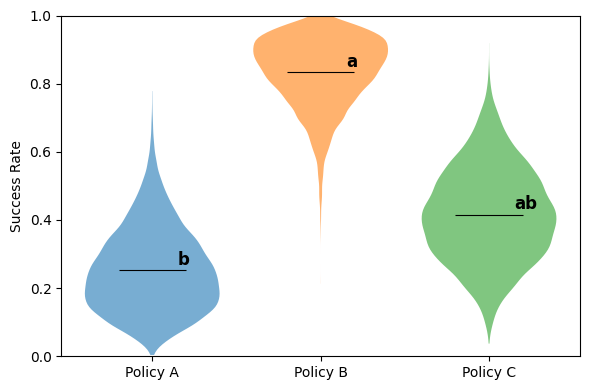

In [5]:
plot_model_comparison(
    model_name_list,
    success_array_list,
    cld_list,
    rng=np.random.default_rng(123), # For plotting violins
)
print("Plot generated. Two models that do not share any CLD letters are significantly different.")

## Note: How to compare aggregated performance across multiple tasks?

When you aggregate results across multiple tasks, keep in mind that the combined sequence does not obey the i.i.d. assumption:

In [9]:
# Task A is a very easy task for Policy A but very hard for Policy B
success_array_policy_a_task_a = [True, True, True, True, True]
success_array_policy_b_task_a = [False, False, False, False, False]

# Task B is a very hard task for Policy A but very easy for Policy B
success_array_policy_a_task_b = [False, False, False, False, False]
success_array_policy_b_task_b = [True, True, True, True, True]

# Combine the success arrays from both tasks to estimate aggregated performance
success_array_policy_a = np.array(success_array_policy_a_task_a + success_array_policy_a_task_b)
success_array_policy_b = np.array(success_array_policy_b_task_a + success_array_policy_b_task_b)

print("Success Array for Policy A:", success_array_policy_a)
print("Success Array for Policy B:", success_array_policy_b)

Success Array for Policy A: [ True  True  True  True  True False False False False False]
Success Array for Policy B: [False False False False False  True  True  True  True  True]


In the example above, the first five results are distributed differently than the rest.

If we are careless, we might reach a wrong conclusion despite both policies having 50% empirical success rates across two tasks:


In [10]:
model_name_list = ["Policy A", "Policy B"]
success_array_list = [
    success_array_policy_a,
    success_array_policy_b,
]

# DO NOT DO THIS IN PRACTICE! This is just for demonstration of how things can go wrong.
# Here, we set shuffle=False, which clearly violates the i.i.d. assumption of the success arrays.
cld_dict = compare_success_and_get_cld(
    model_name_list,
    success_array_list,
    global_confidence_level,
    max_sample_size_per_model,
    shuffle=False,
)

Statistical Test Specs:
  Method: STEP
  Global Confidence: 0.95
    (0.95 per comparison)
  Maximum Sample Size per Model: 15

Statistical Test Results (Compact Letter Display):
  CLD for Policy A: a
    Success Rate 5 / 10 = 0.5
  CLD for Policy B: b
    Success Rate 5 / 10 = 0.5
All models separated with global confidence of 0.95.


Policy A has "a" and Policy B has "b", which is clearly wrong given the same empirical success rate of 50%.

The appropriate setting is to use `shuffle = True`, which shuffles the ordering of each success array internally before running the test.

In [11]:
rng = np.random.default_rng(42)

# DO THIS!
cld_dict = compare_success_and_get_cld(
    model_name_list,
    success_array_list,
    global_confidence_level,
    max_sample_size_per_model,
    verbose=True,
    shuffle=True,
    rng=rng,
)
cld_list = [cld_dict[key] for key in model_name_list]

Statistical Test Specs:
  Method: STEP
  Global Confidence: 0.95
    (0.95 per comparison)
  Maximum Sample Size per Model: 15

Statistical Test Results (Compact Letter Display):
  CLD for Policy A: a
    Success Rate 5 / 10 = 0.5
  CLD for Policy B: a
    Success Rate 5 / 10 = 0.5
Not all models were separated with global confidence of 0.95. Models that share a same letter are not separated from each other with statistical significance. For more information on how to interpret the letters, see: https://en.wikipedia.org/wiki/Compact_letter_display.



This ensures that each input array is an *exchangeable* sequence.
As a result, both Policy A and Policy B have the CLD letter "a", meaning that their true success rates are closely competing each other.

(Note: To be precise, exchangeability is a slightly weaker condition than i.i.d., although we empirically verified that this technicality does not affect the false positive rate of the test.)